# 08 — Clip, Overlay, Dissolve & Spatial Statistics
## Corrected Ring Density, Spatial Weights, Moran's I & Local Spatial Pattern

**กลุ่มผู้เรียน:** ปริญญาตรีปี 3–4 และปริญญาโทปี 1–2 สาขาวิทยาศาสตร์สิ่งแวดล้อม  
**ระดับ:** Intermediate → Advanced  
**ข้อมูล:** Thailand ADM1/ADM2/ADM3 + Village Points  
**เครื่องมือ:** GeoPandas · Pandas · Matplotlib · Folium · PySAL · ESDA

Notebook นี้เป็นบทสรุปของชุด GIS 01–08

ปัญหาที่ต่อมาจาก Notebook 07 คือ:

> วงแหวน 20–200 km รอบอำเภอเมืองพิษณุโลกบางส่วนออกนอกประเทศไทย แต่ village dataset มีเฉพาะประเทศไทย เราจะคำนวณพื้นที่และ density อย่างถูกต้องได้อย่างไร?

จากนั้นต่อด้วยคำถาม:

> เมื่อเรามี village density รายตำบลแล้ว ค่าสูง–ต่ำเหล่านั้นกระจายแบบสุ่ม หรือเกิด spatial clustering?

แกนของบท:

$$
\boxed{
Dissolve
\rightarrow
Clip
\rightarrow
Intersection
\rightarrow
Corrected\ Area
\rightarrow
Density
\rightarrow
Spatial\ Weights
\rightarrow
Moran's\ I
}
$$

## Learning objectives

เมื่อเรียนจบ Notebook นี้ นิสิตควรสามารถ

1. อธิบาย `dissolve`, `clip`, `intersection`, `difference`
2. รวมจังหวัดเป็น Thailand mask ด้วย dissolve
3. Clip concentric rings ให้เหลือเฉพาะพื้นที่ประเทศไทย
4. เปรียบเทียบ full ring area กับ effective ring area
5. คำนวณ corrected village density
6. อธิบายว่าทำไม denominator ที่ไม่ตรง spatial support ทำให้ density ผิด
7. ใช้ `overlay(..., how="intersection")` เพื่อสร้าง Ring × Province pieces
8. ใช้ `difference` เพื่อแสดงพื้นที่ 200-km buffer ที่อยู่นอกประเทศไทย
9. สร้าง village density รายตำบลในพิษณุโลก
10. สร้าง Queen contiguity spatial weights
11. คำนวณและตีความ Global Moran's I
12. อ่าน Moran scatterplot
13. **Advanced/MSc:** คำนวณ Local Moran และ HH/LL/HL/LH
14. **Advanced/MSc:** เปรียบเทียบ Queen, Rook และ KNN weights
15. Export maps, vectors, statistics tables และ interactive HTML

## Recap จาก Notebook 07

Notebook 07 สร้าง

$$
Center
\rightarrow
Distance
\rightarrow
Buffer
\rightarrow
Ring
\rightarrow
Village\ Count
$$

แต่จงใจยังไม่คำนวณ ring density เพราะ

$$
Full\ Ring
\neq
Data\ Coverage
$$

เมื่อข้อมูล village points มีเฉพาะประเทศไทย

วิธีแก้คือ

$$
Effective\ Ring
=
Ring\cap Thailand
$$

## คำถามเปิดบท

สมมติ Ring 180–200 km มีพื้นที่บางส่วนในประเทศเพื่อนบ้าน

แต่ numerator ของเราเป็น:

```text
Thai village points only
```

ถ้า denominator ยังเป็น:

```text
full mathematical ring area
```

numerator และ denominator จะไม่ครอบคลุมพื้นที่เดียวกัน

นี่เรียกว่า **spatial support mismatch**

## หลักสำคัญของบท

$$
\boxed{
Numerator\ and\ denominator
must\ refer\ to\ the\ same\ spatial\ support
}
$$

และในครึ่งหลัง:

> แผนที่ที่ “ดูเหมือน cluster” ยังไม่ใช่หลักฐานทางสถิติว่าเกิด spatial autocorrelation

## 1. ติดตั้ง libraries

In [1]:
%pip -q install geopandas folium xyzservices pyogrio libpysal esda mapclassify

In [2]:
from pathlib import Path
import shutil
import zipfile
import json
import warnings

import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

import folium
import xyzservices.providers as xyz
from folium.plugins import FastMarkerCluster

from libpysal.weights import Queen, Rook, KNN
from libpysal.weights.spatial_lag import lag_spatial
from esda.moran import Moran, Moran_Local

from IPython.display import display

print("GeoPandas:", gpd.__version__)
print("Pandas   :", pd.__version__)
print("Folium   :", folium.__version__)

GeoPandas: 1.2.0
Pandas   : 2.2.3
Folium   : 0.20.0


## 2. Font ภาษาไทย — Sarabun

In [3]:
FONT_URL = (
    "https://raw.githubusercontent.com/"
    "google/fonts/main/ofl/sarabun/Sarabun-Regular.ttf"
)

FONT_FILE = Path("/content/Sarabun-Regular.ttf")

if not FONT_FILE.exists():
    response = requests.get(FONT_URL, timeout=60)
    response.raise_for_status()
    FONT_FILE.write_bytes(response.content)

mpl.font_manager.fontManager.addfont(str(FONT_FILE))

font_name = mpl.font_manager.FontProperties(
    fname=str(FONT_FILE)
).get_name()

mpl.rcParams["font.family"] = font_name
mpl.rcParams["axes.unicode_minus"] = False

print("Thai font ready:", font_name)

Thai font ready: Sarabun


## 3. Workspace

In [4]:
DATA_DIR = Path("/content/gis08_data")
OUTPUT_DIR = Path("/content/gis08_outputs")

DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Data folder   :", DATA_DIR)
print("Output folder :", OUTPUT_DIR)

Data folder   : /content/gis08_data
Output folder : /content/gis08_outputs


## 4. Download helper

In [5]:
def download_and_extract_zip(url, zip_name, extract_name):
    zip_path = DATA_DIR / zip_name
    extract_dir = DATA_DIR / extract_name

    if not zip_path.exists():
        response = requests.get(url, timeout=120)
        response.raise_for_status()
        zip_path.write_bytes(response.content)

    if extract_dir.exists():
        shutil.rmtree(extract_dir)

    extract_dir.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(extract_dir)

    shp_files = list(extract_dir.rglob("*.shp"))

    if not shp_files:
        raise FileNotFoundError(
            f"ไม่พบ .shp ใน {zip_name}"
        )

    print("Shapefile:", shp_files[0])

    return shp_files[0]

## 5. Field helper

In [6]:
def find_column(gdf, candidates, required=False):
    lookup = {
        str(c).upper(): c
        for c in gdf.columns
    }

    for candidate in candidates:
        if candidate.upper() in lookup:
            return lookup[candidate.upper()]

    if required:
        raise KeyError(
            "ไม่พบ field ที่คาดไว้: "
            + ", ".join(candidates)
            + "\nFields จริง: "
            + ", ".join(map(str, gdf.columns))
        )

    return None

## 6. Geometry repair helper

In [7]:
def make_valid_safe(gdf):
    out = gdf.copy()

    try:
        out["geometry"] = out.geometry.make_valid()
    except Exception:
        out["geometry"] = out.geometry.buffer(0)

    return out

# Part A — Load ADM1 + ADM2 + ADM3 + Village Data

## 7. Download all datasets

In [8]:
BASE = (
    "https://raw.githubusercontent.com/"
    "nattaponm/thailand_gis_prasertcbs/main"
)

adm1_shp = download_and_extract_zip(
    f"{BASE}/tha_adm1/tha_adm1_province_shapefile.zip",
    "tha_adm1_province_shapefile.zip",
    "tha_adm1"
)

adm2_shp = download_and_extract_zip(
    f"{BASE}/tha_adm2/tha_admbnda_adm2_shapefile.zip",
    "tha_admbnda_adm2_shapefile.zip",
    "tha_adm2"
)

adm3_shp = download_and_extract_zip(
    f"{BASE}/tambon_simplify/tha_admbnda_adm3_rtsd_20220121.zip",
    "tha_admbnda_adm3_rtsd_20220121.zip",
    "tha_adm3"
)

village_shp = download_and_extract_zip(
    f"{BASE}/village/TH_VILLAGE2012.zip",
    "TH_VILLAGE2012.zip",
    "TH_VILLAGE2012"
)

Shapefile: /content/gis08_data/tha_adm1/tha_adm1_province.shp
Shapefile: /content/gis08_data/tha_adm2/tha_admbnda_adm2.shp
Shapefile: /content/gis08_data/tha_adm3/tha_admbnda_adm3_rtsd_20220121.shp
Shapefile: /content/gis08_data/TH_VILLAGE2012/TH_VILLAGE2012.shp


## 8. Read with UTF-8

In [9]:
province = gpd.read_file(
    adm1_shp,
    encoding="UTF-8"
)

district = gpd.read_file(
    adm2_shp,
    encoding="UTF-8"
)

tambon = gpd.read_file(
    adm3_shp,
    encoding="UTF-8"
)

village = gpd.read_file(
    village_shp,
    encoding="UTF-8"
)

print("Province:", len(province))
print("District:", len(district))
print("Tambon  :", len(tambon))
print("Village :", len(village))

Province: 77
District: 928
Tambon  : 7425
Village : 65213


## 9. Detect administrative fields

In [10]:
p_adm1_code = find_column(
    province,
    ["ADM1_PCODE", "ADM1_CODE"],
    required=True
)

p_adm1_th = find_column(
    province,
    ["ADM1_TH", "NAME_1_TH"],
    required=True
)

d_adm1_th = find_column(
    district,
    ["ADM1_TH", "NAME_1_TH"],
    required=True
)

d_adm2_code = find_column(
    district,
    ["ADM2_PCODE", "ADM2_CODE"],
    required=True
)

d_adm2_th = find_column(
    district,
    ["ADM2_TH", "NAME_2_TH"],
    required=True
)

t_adm1_code = find_column(
    tambon,
    ["ADM1_PCODE", "ADM1_CODE"],
    required=True
)

t_adm1_th = find_column(
    tambon,
    ["ADM1_TH", "NAME_1_TH"],
    required=True
)

t_adm2_code = find_column(
    tambon,
    ["ADM2_PCODE", "ADM2_CODE"],
    required=True
)

t_adm2_th = find_column(
    tambon,
    ["ADM2_TH", "NAME_2_TH"],
    required=True
)

t_adm3_code = find_column(
    tambon,
    ["ADM3_PCODE", "ADM3_CODE"],
    required=True
)

t_adm3_th = find_column(
    tambon,
    ["ADM3_TH", "NAME_3_TH"],
    required=True
)

## 10. Confirm village schema

In [11]:
NAME_FIELD = find_column(
    village,
    ["NAME", "VILL_NAME", "VILLAGE"],
    required=True
)

TAMBON_FIELD = find_column(
    village,
    ["TAM_NAME", "TAMBON", "ADM3_TH"],
    required=True
)

DISTRICT_FIELD = find_column(
    village,
    ["AMP_NAME", "AMPHOE", "ADM2_TH"],
    required=True
)

PROVINCE_FIELD = find_column(
    village,
    ["PRV_NAME", "PROVINCE", "ADM1_TH"],
    required=True
)

print("Village :", NAME_FIELD)
print("Tambon  :", TAMBON_FIELD)
print("District:", DISTRICT_FIELD)
print("Province:", PROVINCE_FIELD)

Village : NAME
Tambon  : TAM_NAME
District: AMP_NAME
Province: PRV_NAME


## 11. Basic geometry QC

In [12]:
qc = pd.DataFrame({
    "Province": [
        len(province),
        province.geometry.isna().sum(),
        (~province.is_valid.fillna(False)).sum()
    ],
    "Tambon": [
        len(tambon),
        tambon.geometry.isna().sum(),
        (~tambon.is_valid.fillna(False)).sum()
    ],
    "Village": [
        len(village),
        village.geometry.isna().sum(),
        (~village.is_valid.fillna(False)).sum()
    ]
}, index=[
    "Features",
    "Missing geometry",
    "Invalid / unavailable"
])

display(qc)

,Province,Tambon,Village
Features,77,7425,65213
Missing geometry,0,0,0
Invalid / unavailable,0,0,0


# Part B — Recreate the 20–200 km Analysis Geometry

## 12. Query Mueang Phitsanulok

In [13]:
mueang_phs = district[
    district[d_adm1_th]
    .astype(str)
    .str.contains(
        "พิษณุโลก",
        na=False
    )
    &
    district[d_adm2_th]
    .astype(str)
    .str.contains(
        "เมืองพิษณุโลก",
        na=False
    )
].copy()

if len(mueang_phs) != 1:
    raise ValueError(
        "คาดว่าจะพบ Mueang Phitsanulok 1 feature "
        f"แต่พบ {len(mueang_phs)}"
    )

display(
    mueang_phs[
        [
            d_adm2_code,
            d_adm1_th,
            d_adm2_th
        ]
    ]
)

,ADM2_PCODE,ADM1_TH,ADM2_TH
683,TH6501,พิษณุโลก,เมืองพิษณุโลก


## 13. Reproject to EPSG:32647 and calculate centroid

In [14]:
mueang_utm = mueang_phs.to_crs(
    "EPSG:32647"
)

origin = (
    mueang_utm.geometry
    .centroid
    .iloc[0]
)

print("Origin X:", origin.x)
print("Origin Y:", origin.y)

Origin X: 636875.9587455936
Origin Y: 1861999.4243243758


## 14. Recreate 20-km concentric rings

In [15]:
radii_km = list(
    range(
        20,
        201,
        20
    )
)

ring_rows = []

inner_km = 0

for outer_km in radii_km:
    outer_geom = origin.buffer(
        outer_km * 1000
    )

    if inner_km == 0:
        ring_geom = outer_geom
    else:
        inner_geom = origin.buffer(
            inner_km * 1000
        )

        ring_geom = outer_geom.difference(
            inner_geom
        )

    ring_rows.append({
        "ring_from_km": inner_km,
        "ring_to_km": outer_km,
        "ring_label": (
            f"{inner_km}–{outer_km} km"
        ),
        "geometry": ring_geom
    })

    inner_km = outer_km

rings = gpd.GeoDataFrame(
    ring_rows,
    geometry="geometry",
    crs="EPSG:32647"
)

display(
    rings[
        [
            "ring_from_km",
            "ring_to_km",
            "ring_label"
        ]
    ]
)

,ring_from_km,ring_to_km,ring_label
0,0,20,0–20 km
1,20,40,20–40 km
2,40,60,40–60 km
3,60,80,60–80 km
4,80,100,80–100 km
5,100,120,100–120 km
6,120,140,120–140 km
7,140,160,140–160 km
8,160,180,160–180 km
9,180,200,180–200 km


## 15. Quick ring map

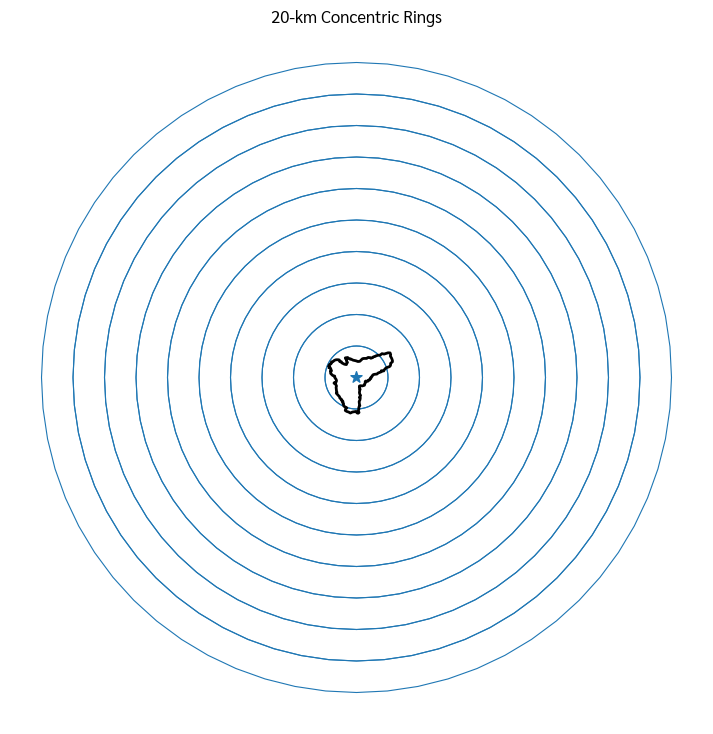

In [16]:
fig, ax = plt.subplots(
    figsize=(9, 9)
)

rings.boundary.plot(
    ax=ax,
    linewidth=0.8
)

mueang_utm.boundary.plot(
    ax=ax,
    color="black",
    linewidth=2
)

gpd.GeoSeries(
    [origin],
    crs="EPSG:32647"
).plot(
    ax=ax,
    markersize=70,
    marker="*"
)

ax.set_title(
    "20-km Concentric Rings"
)
ax.set_axis_off()

plt.show()

# Part C — Dissolve: Provinces → Thailand Mask

## 16. Dissolve concept

เรามี 77 province polygons แต่ต้องการ mask ประเทศไทยเพียง geometry เดียว

$$
Thailand
=
\bigcup_{i=1}^{77}
Province_i
$$

`dissolve()` ใช้รวม polygon หลายชิ้นตามกลุ่ม หรือรวมทั้งหมดเป็น geometry เดียว

## 17. Reproject ADM1 to EPSG:32647

In [17]:
province_utm = province.to_crs(
    "EPSG:32647"
)

province_utm = make_valid_safe(
    province_utm
)

print("CRS:", province_utm.crs)

CRS: EPSG:32647


## 18. Dissolve all provinces

In [18]:
thailand_mask = (
    province_utm[
        ["geometry"]
    ]
    .dissolve()
    .reset_index(drop=True)
)

thailand_mask["country"] = "Thailand"

print(
    "Thailand mask features:",
    len(thailand_mask)
)

print(
    "Geometry type:",
    thailand_mask.geom_type.iloc[0]
)

Thailand mask features: 1
Geometry type: MultiPolygon


## 19. Province boundaries vs dissolved boundary

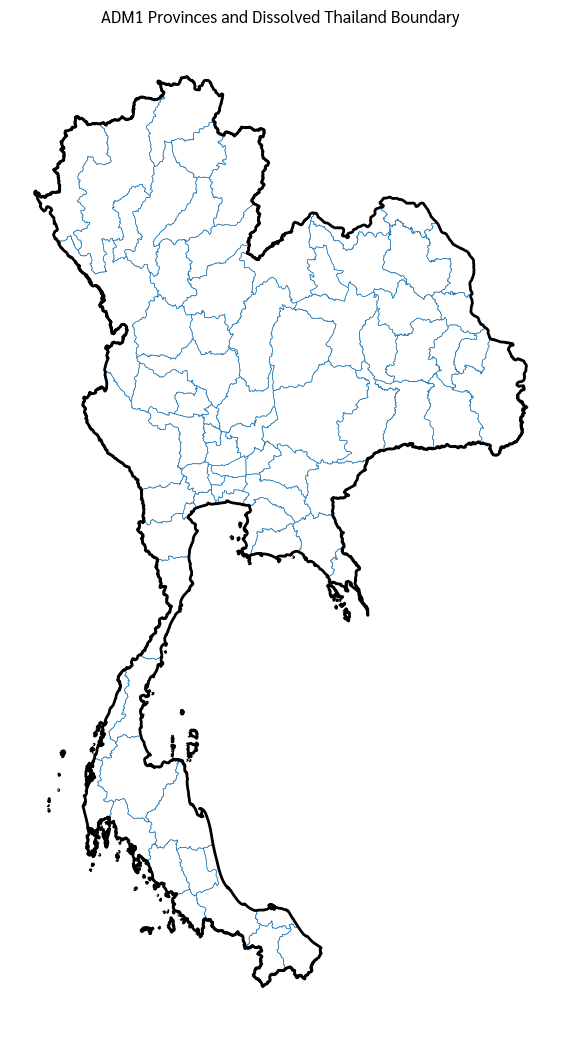

In [19]:
fig, ax = plt.subplots(
    figsize=(9, 13)
)

province_utm.boundary.plot(
    ax=ax,
    linewidth=0.4
)

thailand_mask.boundary.plot(
    ax=ax,
    color="black",
    linewidth=2
)

ax.set_title(
    "ADM1 Provinces and Dissolved Thailand Boundary"
)
ax.set_axis_off()

plt.show()

# Part D — Clip Rings to Thailand

## 20. Clip concept

Clip ตอบคำถาม:

> เอาเฉพาะส่วนของ input geometry ที่อยู่ใน mask

เชิงแนวคิด:

$$
Clipped\ Input
=
Input\cap Mask
$$

## 21. Full theoretical ring area

In [20]:
rings[
    "full_area_km2"
] = (
    rings.geometry.area
    / 1_000_000
)

display(
    rings[
        [
            "ring_label",
            "full_area_km2"
        ]
    ].round(1)
)

,ring_label,full_area_km2
0,0–20 km,1254.6
1,20–40 km,3763.9
2,40–60 km,6273.1
3,60–80 km,8782.3
4,80–100 km,11291.6
5,100–120 km,13800.8
6,120–140 km,16310.1
7,140–160 km,18819.3
8,160–180 km,21328.5
9,180–200 km,23837.8


## 22. Clip rings by Thailand mask

In [21]:
effective_rings = gpd.clip(
    rings,
    thailand_mask
)

effective_rings = make_valid_safe(
    effective_rings
)

print(
    "Effective-ring features:",
    len(effective_rings)
)

Effective-ring features: 10


## 23. Calculate effective area

In [22]:
effective_rings[
    "effective_area_km2"
] = (
    effective_rings.geometry.area
    / 1_000_000
)

ring_area_compare = (
    rings[
        [
            "ring_label",
            "ring_from_km",
            "ring_to_km",
            "full_area_km2"
        ]
    ]
    .merge(
        effective_rings[
            [
                "ring_label",
                "effective_area_km2"
            ]
        ],
        on="ring_label",
        how="left"
    )
)

ring_area_compare[
    "area_retained_pct"
] = (
    100
    * ring_area_compare[
        "effective_area_km2"
    ]
    / ring_area_compare[
        "full_area_km2"
    ]
)

display(
    ring_area_compare.round(2)
)

,ring_label,ring_from_km,ring_to_km,full_area_km2,effective_area_km2,area_retained_pct
0,0–20 km,0,20,1254.62,1254.62,100.00
1,20–40 km,20,40,3763.86,3763.86,100.00
2,40–60 km,40,60,6273.10,6273.10,100.00
3,60–80 km,60,80,8782.34,8782.34,100.00
4,80–100 km,80,100,11291.57,11291.57,100.00
5,100–120 km,100,120,13800.81,13605.50,98.58
6,120–140 km,120,140,16310.05,15621.57,95.78
7,140–160 km,140,160,18819.29,17908.58,95.16
8,160–180 km,160,180,21328.53,19841.44,93.03
9,180–200 km,180,200,23837.77,20749.33,87.04


## 24. Area retained

$$
Area\ Retained(\%)
=
\frac{
A_{effective}
}{
A_{full}
}
\times100
$$

ถ้าเท่ากับ 100% แปลว่า ring นั้นอยู่ภายในประเทศไทยทั้งหมด

## 25. Which ring is most truncated?

In [23]:
most_truncated = (
    ring_area_compare
    .sort_values(
        "area_retained_pct"
    )
    .head(3)
)

display(
    most_truncated.round(2)
)

,ring_label,ring_from_km,ring_to_km,full_area_km2,effective_area_km2,area_retained_pct
9,180–200 km,180,200,23837.77,20749.33,87.04
8,160–180 km,160,180,21328.53,19841.44,93.03
7,140–160 km,140,160,18819.29,17908.58,95.16


## 26. Map clipped/effective rings

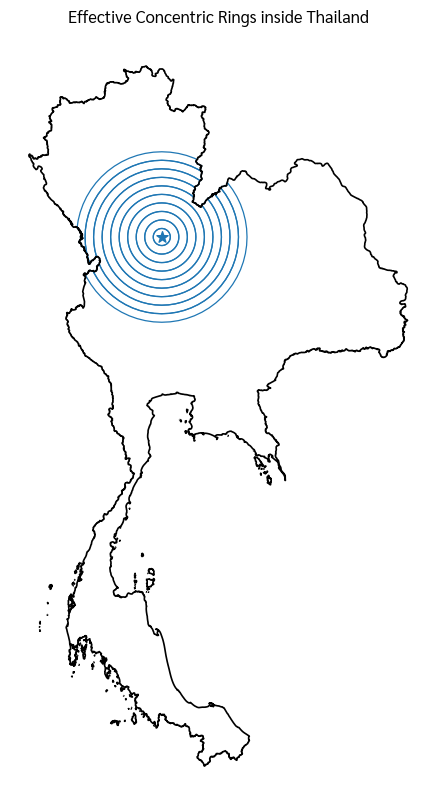

In [24]:
fig_effective, ax = plt.subplots(
    figsize=(10, 10)
)

effective_rings.boundary.plot(
    ax=ax,
    linewidth=0.9
)

thailand_mask.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1.2
)

gpd.GeoSeries(
    [origin],
    crs="EPSG:32647"
).plot(
    ax=ax,
    markersize=70,
    marker="*"
)

ax.set_title(
    "Effective Concentric Rings inside Thailand"
)
ax.set_axis_off()

plt.show()

# Part E — Corrected Village Density by Ring

## 27. Reproject village points and calculate distance

In [25]:
village_utm = village.to_crs(
    "EPSG:32647"
)

village_utm[
    "distance_km"
] = (
    village_utm.geometry.distance(
        origin
    )
    / 1000
)

village_200 = village_utm[
    village_utm[
        "distance_km"
    ] <= 200
].copy()

print(
    "Village points within 200 km:",
    len(village_200)
)

Village points within 200 km: 10667


## 28. Assign 20-km distance rings

In [26]:
bins = [
    0, 20, 40, 60, 80, 100,
    120, 140, 160, 180, 200
]

ring_labels = [
    f"{bins[i]}–{bins[i+1]} km"
    for i in range(
        len(bins) - 1
    )
]

village_200[
    "ring_label"
] = pd.cut(
    village_200[
        "distance_km"
    ],
    bins=bins,
    labels=ring_labels,
    include_lowest=True,
    right=True
)

display(
    village_200[
        [
            NAME_FIELD,
            PROVINCE_FIELD,
            "distance_km",
            "ring_label"
        ]
    ].head(10)
)

,NAME,PRV_NAME,distance_km,ring_label
0,บ้านท่าลานเตียน,ชัยนาท,158.777351,140–160 km
1,บ้านหนองสะแก,ชัยนาท,159.139834,140–160 km
2,บ้านหัวยาง,ชัยนาท,159.175137,140–160 km
3,บ้านสะพานหิน,ชัยนาท,159.485113,140–160 km
4,บ้านทุ่งประพาส,ชัยนาท,160.473799,160–180 km
5,บ้านหางน้ำหนองแขม,ชัยนาท,160.010132,160–180 km
6,บ้านหลั่น,ชัยนาท,160.575229,160–180 km
7,บ้านหางน้ำหนองแขม,ชัยนาท,160.851410,160–180 km
8,ท่าฉนวน,ชัยนาท,161.480771,160–180 km
9,บ้านทุ่งใหญ่,ชัยนาท,161.735394,160–180 km


## 29. Village count per ring

In [27]:
ring_counts = (
    village_200[
        "ring_label"
    ]
    .value_counts(
        sort=False
    )
    .rename_axis(
        "ring_label"
    )
    .reset_index(
        name="village_count"
    )
)

ring_counts[
    "ring_label"
] = ring_counts[
    "ring_label"
].astype(str)

display(ring_counts)

,ring_label,village_count
0,0–20 km,227
1,20–40 km,468
2,40–60 km,712
3,60–80 km,951
4,80–100 km,1405
5,100–120 km,1340
6,120–140 km,1118
7,140–160 km,1318
8,160–180 km,1543
9,180–200 km,1585


## 30. Join counts to effective ring areas

In [28]:
ring_density = (
    ring_area_compare
    .merge(
        ring_counts,
        on="ring_label",
        how="left"
    )
)

ring_density[
    "village_count"
] = (
    ring_density[
        "village_count"
    ]
    .fillna(0)
    .astype(int)
)

display(
    ring_density.round(3)
)

,ring_label,ring_from_km,ring_to_km,full_area_km2,effective_area_km2,area_retained_pct,village_count
0,0–20 km,0,20,1254.619,1254.619,100.000,227
1,20–40 km,20,40,3763.858,3763.858,100.000,468
2,40–60 km,40,60,6273.097,6273.097,100.000,712
3,60–80 km,60,80,8782.336,8782.336,100.000,951
4,80–100 km,80,100,11291.575,11291.575,100.000,1405
5,100–120 km,100,120,13800.813,13605.496,98.585,1340
6,120–140 km,120,140,16310.052,15621.575,95.779,1118
7,140–160 km,140,160,18819.291,17908.576,95.161,1318
8,160–180 km,160,180,21328.530,19841.437,93.028,1543
9,180–200 km,180,200,23837.769,20749.330,87.044,1585


## 31. Corrected vs naive density

Naive:

$$
D_{naive}
=
\frac{
N_{villages}
}{
A_{full\ ring}
}
$$

Corrected:

$$
D_{corrected}
=
\frac{
N_{villages}
}{
A_{effective\ ring}
}
$$

In [29]:
ring_density[
    "density_naive"
] = (
    ring_density[
        "village_count"
    ]
    / ring_density[
        "full_area_km2"
    ]
)

ring_density[
    "density_corrected"
] = (
    ring_density[
        "village_count"
    ]
    / ring_density[
        "effective_area_km2"
    ]
)

ring_density[
    "density_bias_pct"
] = (
    100
    * (
        ring_density[
            "density_naive"
        ]
        -
        ring_density[
            "density_corrected"
        ]
    )
    / ring_density[
        "density_corrected"
    ]
)

display(
    ring_density[
        [
            "ring_label",
            "village_count",
            "full_area_km2",
            "effective_area_km2",
            "density_naive",
            "density_corrected",
            "density_bias_pct"
        ]
    ].round(4)
)

,ring_label,village_count,full_area_km2,effective_area_km2,density_naive,density_corrected,density_bias_pct
0,0–20 km,227,1254.6194,1254.6194,0.1809,0.1809,-0.0000
1,20–40 km,468,3763.8582,3763.8582,0.1243,0.1243,-0.0000
2,40–60 km,712,6273.0970,6273.0970,0.1135,0.1135,0.0000
3,60–80 km,951,8782.3358,8782.3358,0.1083,0.1083,-0.0000
4,80–100 km,1405,11291.5746,11291.5746,0.1244,0.1244,0.0000
5,100–120 km,1340,13800.8134,13605.4964,0.0971,0.0985,-1.4153
6,120–140 km,1118,16310.0522,15621.5745,0.0685,0.0716,-4.2212
7,140–160 km,1318,18819.2909,17908.5764,0.0700,0.0736,-4.8393
8,160–180 km,1543,21328.5297,19841.4366,0.0723,0.0778,-6.9723
9,180–200 km,1585,23837.7685,20749.3299,0.0665,0.0764,-12.9561


ค่า `density_bias_pct` ติดลบ หมายถึงการใช้ full ring area ทำให้ density ต่ำกว่าค่าที่ใช้ spatial support ตรงกับข้อมูลจริง

## 32. Compare naive vs corrected density

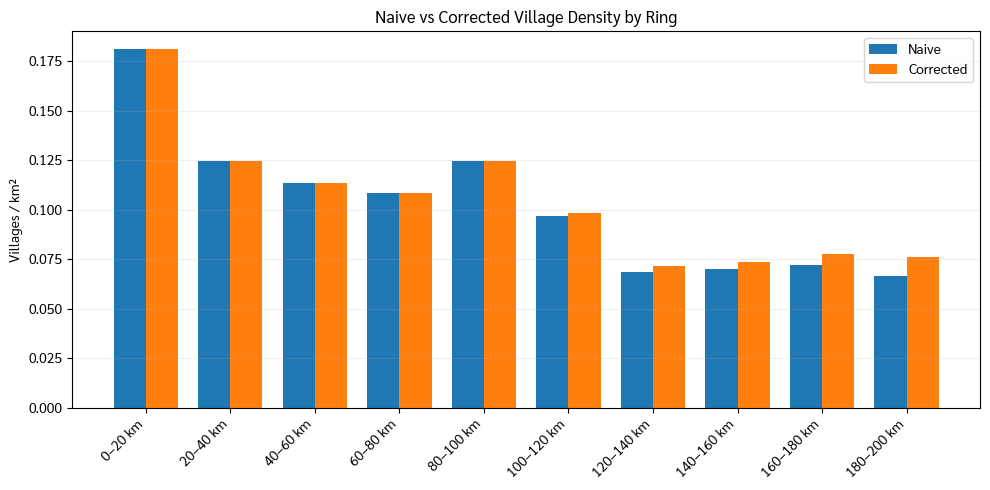

In [30]:
fig_density_compare, ax = plt.subplots(
    figsize=(10, 5)
)

x = np.arange(
    len(ring_density)
)

width = 0.38

ax.bar(
    x - width/2,
    ring_density[
        "density_naive"
    ],
    width,
    label="Naive"
)

ax.bar(
    x + width/2,
    ring_density[
        "density_corrected"
    ],
    width,
    label="Corrected"
)

ax.set_xticks(x)

ax.set_xticklabels(
    ring_density[
        "ring_label"
    ],
    rotation=45,
    ha="right"
)

ax.set_ylabel(
    "Villages / km²"
)

ax.set_title(
    "Naive vs Corrected Village Density by Ring"
)

ax.legend()
ax.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()
plt.show()

## 33. Add corrected density to effective-ring geometry

In [31]:
effective_rings_stats = (
    effective_rings
    .merge(
        ring_density[
            [
                "ring_label",
                "village_count",
                "density_corrected",
                "density_naive",
                "area_retained_pct"
            ]
        ],
        on="ring_label",
        how="left"
    )
)

display(
    effective_rings_stats[
        [
            "ring_label",
            "village_count",
            "density_corrected",
            "area_retained_pct"
        ]
    ].round(3)
)

,ring_label,village_count,density_corrected,area_retained_pct
0,0–20 km,227,0.181,100.000
1,20–40 km,468,0.124,100.000
2,40–60 km,712,0.114,100.000
3,60–80 km,951,0.108,100.000
4,80–100 km,1405,0.124,100.000
5,100–120 km,1340,0.098,98.585
6,120–140 km,1118,0.072,95.779
7,140–160 km,1318,0.074,95.161
8,160–180 km,1543,0.078,93.028
9,180–200 km,1585,0.076,87.044


## 34. Corrected-density ring map

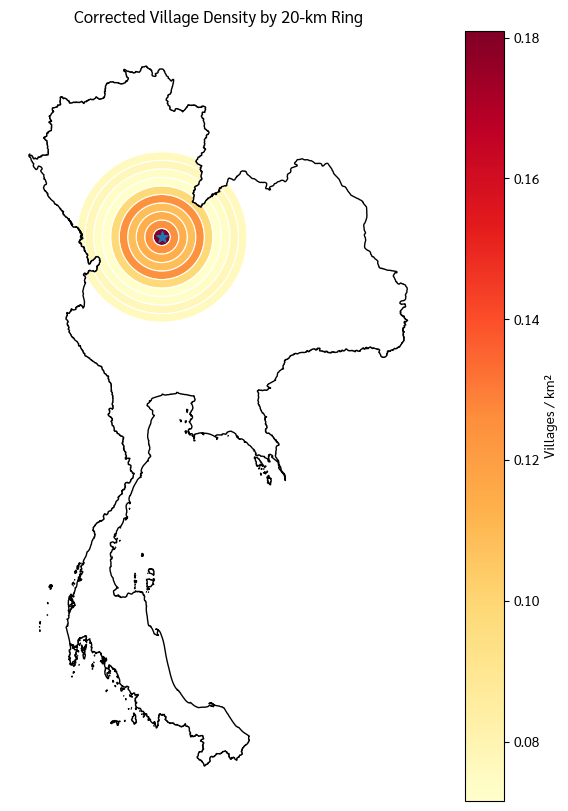

In [32]:
fig_corrected_ring, ax = plt.subplots(
    figsize=(10, 10)
)

effective_rings_stats.plot(
    ax=ax,
    column="density_corrected",
    cmap="YlOrRd",
    legend=True,
    edgecolor="white",
    linewidth=0.8,
    legend_kwds={
        "label": "Villages / km²"
    }
)

thailand_mask.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1.0
)

gpd.GeoSeries(
    [origin],
    crs="EPSG:32647"
).plot(
    ax=ax,
    markersize=70,
    marker="*"
)

ax.set_title(
    "Corrected Village Density by 20-km Ring"
)
ax.set_axis_off()

plt.show()

# Part F — Intersection: Ring × Province

## 35. Clip vs Intersection

### Clip

ตอบว่า:

> เอาส่วน input ที่อยู่ใน mask

### Intersection

ตอบว่า:

> พื้นที่ที่ A และ B ซ้อนกันคืออะไร และต้องการ attributes จากทั้งสอง layer

`intersection` จึงเหมาะกับการสร้าง:

```text
Ring × Province pieces
```

## 36. Prepare province layer for overlay

In [33]:
province_overlay = province_utm[
    [
        p_adm1_code,
        p_adm1_th,
        "geometry"
    ]
].copy()

province_overlay = make_valid_safe(
    province_overlay
)

## 37. Overlay rings with provinces

In [34]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    ring_province = gpd.overlay(
        rings,
        province_overlay,
        how="intersection",
        keep_geom_type=False
    )

ring_province[
    "piece_area_km2"
] = (
    ring_province.geometry.area
    / 1_000_000
)

print(
    "Ring × Province pieces:",
    len(ring_province)
)

display(
    ring_province[
        [
            "ring_label",
            p_adm1_th,
            "piece_area_km2"
        ]
    ].head(15)
)

Ring × Province pieces: 99


,ring_label,ADM1_TH,piece_area_km2
0,0–20 km,พิษณุโลก,1254.619396
1,20–40 km,อุตรดิตถ์,0.934149
2,20–40 km,สุโขทัย,319.000626
3,20–40 km,พิษณุโลก,3099.032145
4,20–40 km,พิจิตร,344.891269
5,40–60 km,อุตรดิตถ์,586.339501
6,40–60 km,กำแพงเพชร,542.230274
7,40–60 km,สุโขทัย,1068.098879
8,40–60 km,พิษณุโลก,2747.761620
9,40–60 km,พิจิตร,1328.666708


## 38. Group area by Ring × Province

In [35]:
ring_province_area = (
    ring_province
    .groupby(
        [
            "ring_label",
            p_adm1_code,
            p_adm1_th
        ],
        as_index=False
    )
    .agg(
        area_km2=(
            "piece_area_km2",
            "sum"
        )
    )
)

display(
    ring_province_area
    .sort_values(
        [
            "ring_label",
            "area_km2"
        ],
        ascending=[
            True,
            False
        ]
    )
    .head(25)
)

,ring_label,ADM1_PCODE,ADM1_TH,area_km2
0,0–20 km,TH65,พิษณุโลก,1254.619396
11,100–120 km,TH67,เพชรบูรณ์,2989.271431
6,100–120 km,TH62,กำแพงเพชร,2034.563927
5,100–120 km,TH60,นครสวรรค์,2008.458537
3,100–120 km,TH53,อุตรดิตถ์,1847.282738
8,100–120 km,TH64,สุโขทัย,1387.138822
7,100–120 km,TH63,ตาก,1177.740490
1,100–120 km,TH42,เลย,1114.846494
2,100–120 km,TH52,ลำปาง,390.069948
4,100–120 km,TH54,แพร่,289.201943


## 39. Focus on the 180–200 km ring

In [36]:
outer_ring_provinces = (
    ring_province_area[
        ring_province_area[
            "ring_label"
        ] == "180–200 km"
    ]
    .sort_values(
        "area_km2",
        ascending=False
    )
)

display(
    outer_ring_provinces.round(2)
)

,ring_label,ADM1_PCODE,ADM1_TH,area_km2
70,180–200 km,TH63,ตาก,3273.83
58,180–200 km,TH36,ชัยภูมิ,2786.68
64,180–200 km,TH52,ลำปาง,2361.84
61,180–200 km,TH42,เลย,2025.68
69,180–200 km,TH61,อุทัยธานี,1662.49
55,180–200 km,TH16,ลพบุรี,1660.18
67,180–200 km,TH55,น่าน,1407.22
57,180–200 km,TH18,ชัยนาท,1208.92
63,180–200 km,TH51,ลำพูน,1119.06
60,180–200 km,TH40,ขอนแก่น,742.38


## 40. Map Ring × Province pieces

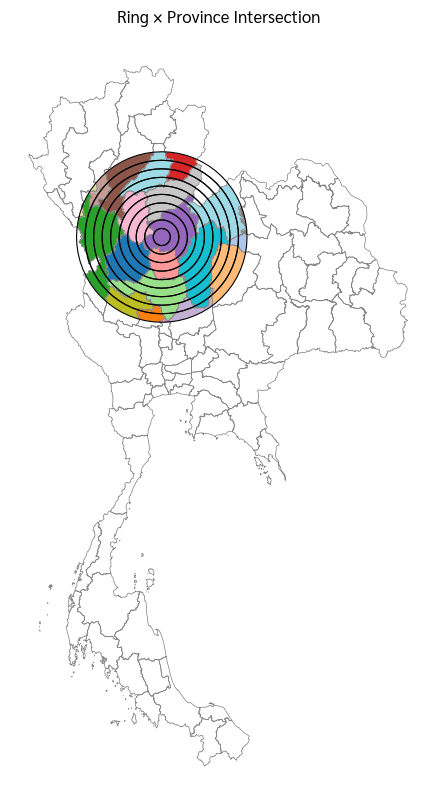

In [37]:
fig_intersection, ax = plt.subplots(
    figsize=(10, 10)
)

ring_province.plot(
    ax=ax,
    column=p_adm1_th,
    categorical=True,
    legend=False,
    edgecolor="white",
    linewidth=0.3
)

province_utm.boundary.plot(
    ax=ax,
    color="gray",
    linewidth=0.5
)

rings.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.8
)

ax.set_title(
    "Ring × Province Intersection"
)
ax.set_axis_off()

plt.show()

## 41. Province area within the 200-km study zone

In [38]:
province_area_200km = (
    ring_province
    .groupby(
        [
            p_adm1_code,
            p_adm1_th
        ],
        as_index=False
    )
    .agg(
        area_within_200km=(
            "piece_area_km2",
            "sum"
        )
    )
    .sort_values(
        "area_within_200km",
        ascending=False
    )
)

display(
    province_area_200km.head(15).round(1)
)

,ADM1_PCODE,ADM1_TH,area_within_200km
16,TH63,ตาก,13056.1
20,TH67,เพชรบูรณ์,12395.0
18,TH65,พิษณุโลก,10522.8
13,TH60,นครสวรรค์,9509.2
6,TH42,เลย,9199.1
15,TH62,กำแพงเพชร,8552.6
10,TH53,อุตรดิตถ์,7917.6
9,TH52,ลำปาง,7525.2
3,TH36,ชัยภูมิ,7398.1
17,TH64,สุโขทัย,6675.5


## 42. Bar chart: provinces contributing most area

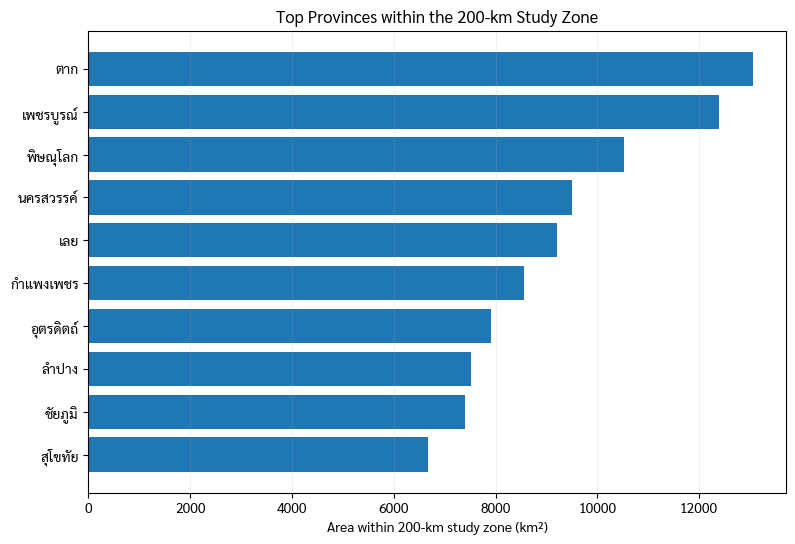

In [39]:
top_provinces = (
    province_area_200km
    .head(10)
    .sort_values(
        "area_within_200km"
    )
)

fig, ax = plt.subplots(
    figsize=(9, 6)
)

ax.barh(
    top_provinces[
        p_adm1_th
    ],
    top_provinces[
        "area_within_200km"
    ]
)

ax.set_xlabel(
    "Area within 200-km study zone (km²)"
)

ax.set_title(
    "Top Provinces within the 200-km Study Zone"
)

ax.grid(
    axis="x",
    alpha=0.2
)

plt.show()

# Part G — Difference: What Lies Outside Thailand?

## 43. Difference concept

`difference` ตอบคำถาม:

> ส่วนของ A ที่อยู่นอก B คืออะไร?

$$
A-B
$$

ในที่นี้:

$$
200km\ Buffer
-
Thailand
$$

## 44. Create 200-km buffer

In [40]:
buffer_200 = gpd.GeoDataFrame(
    {
        "radius_km": [200]
    },
    geometry=[
        origin.buffer(
            200 * 1000
        )
    ],
    crs="EPSG:32647"
)

## 45. Difference: 200-km buffer outside Thailand

In [41]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    outside_thailand = gpd.overlay(
        buffer_200,
        thailand_mask[
            ["geometry"]
        ],
        how="difference",
        keep_geom_type=False
    )

outside_area_km2 = (
    outside_thailand.geometry.area.sum()
    / 1_000_000
)

full_200_area_km2 = (
    buffer_200.geometry.area.iloc[0]
    / 1_000_000
)

outside_pct = (
    100
    * outside_area_km2
    / full_200_area_km2
)

print(
    f"Outside-Thailand area: "
    f"{outside_area_km2:,.1f} km²"
)

print(
    f"Percent of 200-km buffer outside Thailand: "
    f"{outside_pct:.2f}%"
)

Outside-Thailand area: 6,370.0 km²
Percent of 200-km buffer outside Thailand: 5.08%


## 46. Map the outside portion

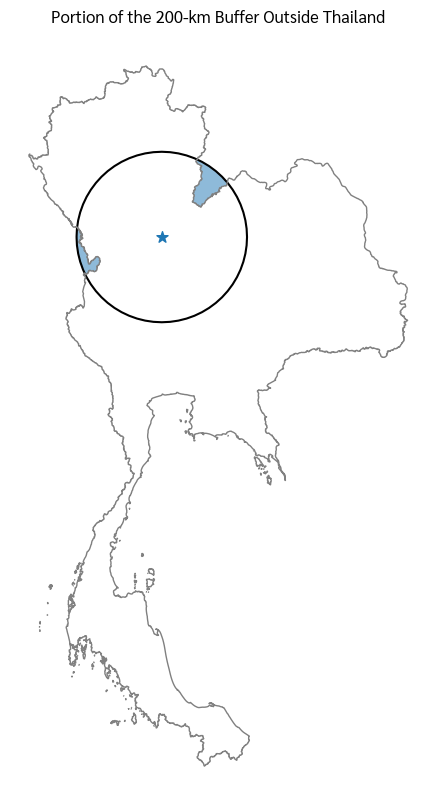

In [42]:
fig, ax = plt.subplots(
    figsize=(10, 10)
)

buffer_200.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1.5
)

thailand_mask.boundary.plot(
    ax=ax,
    color="gray",
    linewidth=1
)

outside_thailand.plot(
    ax=ax,
    alpha=0.5
)

gpd.GeoSeries(
    [origin],
    crs="EPSG:32647"
).plot(
    ax=ax,
    markersize=70,
    marker="*"
)

ax.set_title(
    "Portion of the 200-km Buffer Outside Thailand"
)
ax.set_axis_off()

plt.show()

# Part H — Choosing the Right GIS Operation

## 47. Spatial operations summary

| Operation | คำถามหลัก |
|---|---|
| Spatial Join | Feature นี้สัมพันธ์เชิงตำแหน่งกับ feature ไหน? |
| Dissolve | รวม polygon หลายชิ้นให้เป็นกลุ่มเดียวได้ไหม? |
| Clip | เอาเฉพาะส่วน input ที่อยู่ใน mask |
| Intersection | พื้นที่ที่สอง layer ซ้อนกันคืออะไร พร้อม attributes ทั้งสองฝั่ง |
| Difference | ส่วนของ A ที่อยู่นอก B คืออะไร? |

หลัก:

> เลือก operation จากคำถาม ไม่ใช่จำชื่อคำสั่งแล้วค่อยหางานให้มันทำ

# Part I — From Choropleth to Spatial Statistics

## 48. คำถามใหม่

หลังแก้ geometry และ spatial support แล้ว เรากลับมาที่พิษณุโลก

คำถาม:

> Tambons ที่มี village density สูงอยู่ใกล้ tambons ที่มี density สูงด้วยหรือไม่?

ถ้าใช่ อาจมี **positive spatial autocorrelation**

## 49. Select Phitsanulok Tambons

In [43]:
phs_tambon = tambon[
    tambon[t_adm1_th]
    .astype(str)
    .str.contains(
        "พิษณุโลก",
        na=False
    )
].copy()

phs_tambon_utm = (
    phs_tambon
    .to_crs(
        "EPSG:32647"
    )
)

phs_tambon_utm = make_valid_safe(
    phs_tambon_utm
)

print(
    "Phitsanulok Tambons:",
    len(phs_tambon_utm)
)

Phitsanulok Tambons: 93


## 50. Spatial join Village → Phitsanulok Tambon

In [44]:
phs_join_layer = phs_tambon_utm[
    [
        t_adm3_code,
        t_adm3_th,
        t_adm2_code,
        t_adm2_th,
        "geometry"
    ]
].copy()

village_phs_joined = gpd.sjoin(
    village_utm,
    phs_join_layer,
    how="inner",
    predicate="within"
)

print(
    "Village points joined to Phitsanulok Tambons:",
    len(village_phs_joined)
)

Village points joined to Phitsanulok Tambons: 863


## 51. Village count per Tambon

In [45]:
phs_count = (
    village_phs_joined
    .groupby(
        t_adm3_code,
        as_index=False
    )
    .size()
    .rename(
        columns={
            "size": "village_count"
        }
    )
)

phs_stats = (
    phs_tambon_utm
    .merge(
        phs_count,
        on=t_adm3_code,
        how="left"
    )
)

phs_stats[
    "village_count"
] = (
    phs_stats[
        "village_count"
    ]
    .fillna(0)
    .astype(int)
)

## 52. Area and village density

In [46]:
phs_stats[
    "area_km2"
] = (
    phs_stats.geometry.area
    / 1_000_000
)

phs_stats[
    "village_density"
] = (
    phs_stats[
        "village_count"
    ]
    / phs_stats[
        "area_km2"
    ]
)

phs_stats = (
    phs_stats
    .reset_index(drop=True)
)

display(
    phs_stats[
        [
            t_adm2_th,
            t_adm3_th,
            "village_count",
            "area_km2",
            "village_density"
        ]
    ]
    .sort_values(
        "village_density",
        ascending=False
    )
    .head(15)
    .round(3)
)

,ADM2_TH,ADM3_TH,village_count,area_km2,village_density
13,เมืองพิษณุโลก,บ้านคลอง,5,8.248,0.606
50,บางกระทุ่ม,โคกสลุด,11,20.119,0.547
9,เมืองพิษณุโลก,ปากโทก,8,16.197,0.494
11,เมืองพิษณุโลก,จอมทอง,8,18.121,0.441
14,เมืองพิษณุโลก,พลายชุมพล,5,12.971,0.385
49,บางกระทุ่ม,บ้านไร่,11,28.635,0.384
4,เมืองพิษณุโลก,ท่าทอง,8,23.041,0.347
15,เมืองพิษณุโลก,มะขามสูง,9,26.433,0.340
20,นครไทย,นครไทย,12,38.197,0.314
2,เมืองพิษณุโลก,วัดจันทร์,4,12.920,0.310


## 53. Descriptive statistics

In [47]:
display(
    phs_stats[
        "village_density"
    ]
    .describe()
    .to_frame(
        "village_density"
    )
    .round(4)
)

,village_density
count,93.0000
mean,0.1502
std,0.1280
min,0.0000
25%,0.0459
50%,0.1298
75%,0.2063
max,0.6062


## 54. Choropleth before spatial statistics

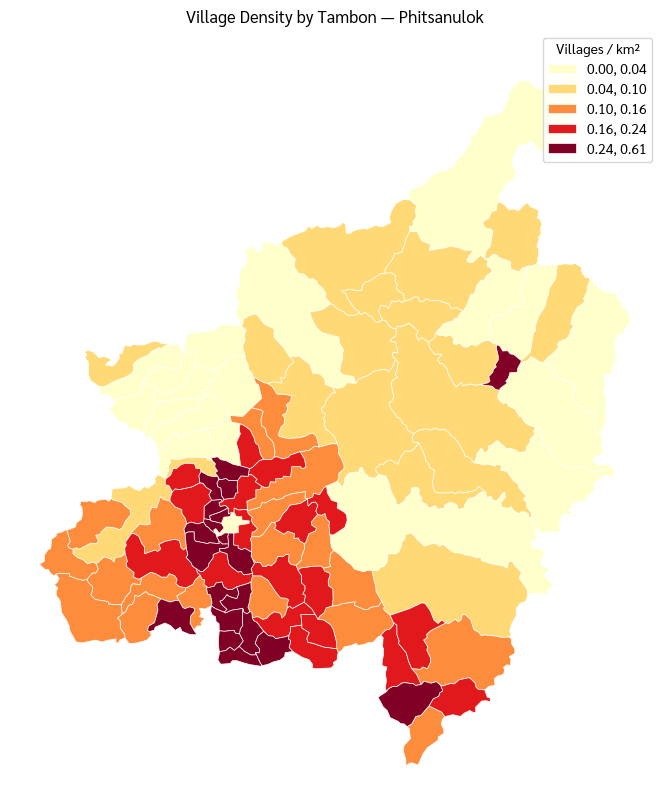

In [48]:
fig_phs_density, ax = plt.subplots(
    figsize=(9, 10)
)

phs_stats.plot(
    ax=ax,
    column="village_density",
    scheme="Quantiles",
    k=5,
    cmap="YlOrRd",
    legend=True,
    edgecolor="white",
    linewidth=0.5,
    legend_kwds={
        "title": "Villages / km²"
    }
)

ax.set_title(
    "Village Density by Tambon — Phitsanulok"
)
ax.set_axis_off()

plt.show()

แผนที่อาจ “ดูเหมือนมี cluster” แต่สายตาอย่างเดียวไม่สามารถบอกได้ว่า pattern แตกต่างจาก spatial randomness มากน้อยเพียงใด

# Part J — Spatial Weights

## 55. What is a spatial neighbor?

Spatial statistics ต้องกำหนดก่อนว่า

> ใครเป็นเพื่อนบ้านของใคร?

ในบทนี้ใช้ **Queen contiguity**

สอง polygon เป็น neighbors ถ้าแชร์

- edge หรือ
- vertex

แนวคิดนี้คล้ายการเดินของ Queen ในหมากรุก

## 56. Build Queen weights

In [49]:
w_queen = Queen.from_dataframe(
    phs_stats,
    use_index=True
)

print(
    "Number of spatial units:",
    w_queen.n
)

print(
    "Islands:",
    w_queen.islands
)

Number of spatial units: 93
Islands: []


## 57. Inspect neighbors of one Tambon

In [50]:
example_idx = 0

neighbor_ids = (
    w_queen.neighbors[
        example_idx
    ]
)

print(
    "Example Tambon:",
    phs_stats.loc[
        example_idx,
        t_adm3_th
    ]
)

print(
    "Neighbor indices:",
    neighbor_ids
)

if neighbor_ids:
    display(
        phs_stats.loc[
            neighbor_ids,
            [
                t_adm2_th,
                t_adm3_th
            ]
        ]
    )

Example Tambon: ในเมือง
Neighbor indices: [16, 17, 2, 10, 13]


,ADM2_TH,ADM3_TH
16,เมืองพิษณุโลก,อรัญญิก
17,เมืองพิษณุโลก,บึงพระ
2,เมืองพิษณุโลก,วัดจันทร์
10,เมืองพิษณุโลก,หัวรอ
13,เมืองพิษณุโลก,บ้านคลอง


## 58. Number of neighbors per Tambon

In [51]:
phs_stats[
    "n_neighbors"
] = [
    len(
        w_queen.neighbors[i]
    )
    for i in phs_stats.index
]

display(
    phs_stats[
        [
            t_adm3_th,
            "n_neighbors"
        ]
    ]
    .sort_values(
        "n_neighbors",
        ascending=False
    )
    .head(15)
)

,ADM3_TH,n_neighbors
7,ดอนทอง,10
10,หัวรอ,10
82,วังนกแอ่น,9
21,หนองกะท้าว,8
3,วัดพริก,8
43,ชุมแสงสงคราม,8
78,บ้านกลาง,8
15,มะขามสูง,8
12,บ้านกร่าง,7
37,บางระกำ,7


ถ้า `w_queen.islands` ไม่ว่าง แปลว่ามี polygon ที่ไม่มี Queen neighbor ใน layer นี้ ต้องตรวจ geometry และเลือก weights ให้เหมาะสมก่อนตีความสถิติ

## 59. Row-standardize weights

In [52]:
w_queen.transform = "R"

print(
    "Weights transformation:",
    w_queen.transform
)

Weights transformation: R


# Part K — Global Moran's I

## 60. Global Moran's I

$$
I=
\frac{n}{S_0}
\frac{
\sum_i\sum_j
w_{ij}
(x_i-\bar{x})
(x_j-\bar{x})
}{
\sum_i
(x_i-\bar{x})^2
}
$$

ตีความแบบง่าย:

```text
I > expected
→ similar values tend to be near each other

I ≈ expected
→ pattern closer to spatial randomness

I < expected
→ dissimilar values tend to be neighbors
```

## 61. Expected Moran's I under randomness

โดยประมาณ:

$$
E[I]
=
-\frac{1}{n-1}
$$

ดังนั้นไม่ควรเปรียบเทียบกับ 0 อย่างเดียว

## 62. Compute Global Moran's I

In [53]:
y = (
    phs_stats[
        "village_density"
    ]
    .to_numpy()
)

moran_global = Moran(
    y,
    w_queen,
    permutations=999
)

global_moran_table = pd.DataFrame({
    "Statistic": [
        "Moran_I",
        "Expected_I",
        "Permutation_p",
        "Permutations"
    ],
    "Value": [
        moran_global.I,
        moran_global.EI,
        moran_global.p_sim,
        moran_global.permutations
    ]
})

display(
    global_moran_table
)

,Statistic,Value
0,Moran_I,0.492599
1,Expected_I,-0.010870
2,Permutation_p,0.001000
3,Permutations,999.000000


## 63. Interpretation rule

อย่าตีความจาก `I` เพียงอย่างเดียว

พิจารณาร่วมกัน:

```text
Observed I
Expected I
Permutation p-value
Map pattern
Variable definition
Spatial weights
```

> Statistical significance ไม่ได้อธิบายสาเหตุของ spatial pattern

# Part L — Moran Scatterplot

## 64. Standardize the variable

$$
z_i=
\frac{
x_i-\bar{x}
}{
s
}
$$

In [54]:
z = (
    y - y.mean()
) / y.std(
    ddof=0
)

spatial_lag_z = lag_spatial(
    w_queen,
    z
)

phs_stats["z_density"] = z
phs_stats["lag_z_density"] = spatial_lag_z

## 65. Moran scatterplot

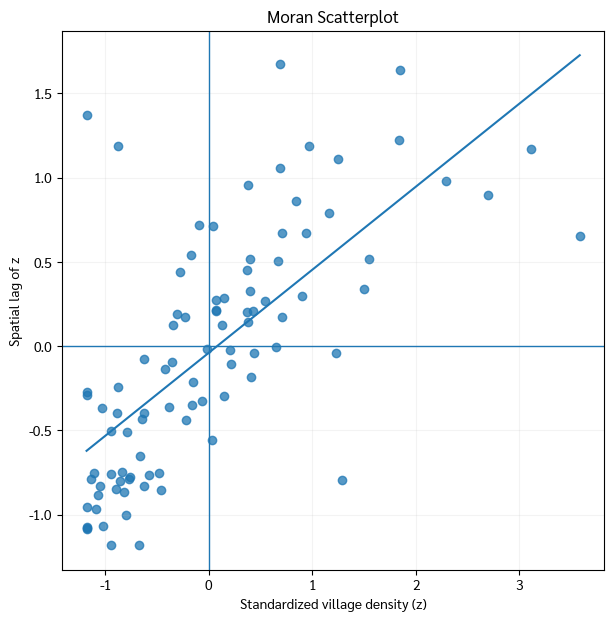

In [55]:
fig_moran_scatter, ax = plt.subplots(
    figsize=(7, 7)
)

ax.scatter(
    z,
    spatial_lag_z,
    alpha=0.75
)

ax.axhline(
    0,
    linewidth=1
)

ax.axvline(
    0,
    linewidth=1
)

slope, intercept = np.polyfit(
    z,
    spatial_lag_z,
    1
)

x_line = np.linspace(
    z.min(),
    z.max(),
    100
)

ax.plot(
    x_line,
    slope * x_line + intercept,
    linewidth=1.5
)

ax.set_xlabel(
    "Standardized village density (z)"
)

ax.set_ylabel(
    "Spatial lag of z"
)

ax.set_title(
    "Moran Scatterplot"
)

ax.grid(alpha=0.15)

plt.show()

## 66. Quadrants

```text
HH: High surrounded by High
LL: Low surrounded by Low
HL: High surrounded by Low
LH: Low surrounded by High
```

Moran scatterplot ช่วยให้เห็นลักษณะ local spatial association เชิงแนวคิด แต่ยังไม่ใช่ significance test รายพื้นที่

# Part M — Advanced / MSc: Local Moran

## 67. Global vs Local

Global Moran's I ตอบ:

> โดยรวมทั้งพื้นที่มี spatial autocorrelation หรือไม่?

Local Moran ตอบ:

> spatial association ที่เด่นอยู่ตรงไหน?

## 68. Compute Local Moran

In [56]:
local_moran = Moran_Local(
    y,
    w_queen,
    permutations=999
)

phs_stats[
    "local_I"
] = local_moran.Is

phs_stats[
    "local_p"
] = local_moran.p_sim

phs_stats[
    "local_q"
] = local_moran.q

## 69. Assign HH / LH / LL / HL

In [57]:
quadrant_map = {
    1: "HH",
    2: "LH",
    3: "LL",
    4: "HL"
}

phs_stats[
    "local_cluster"
] = [
    (
        quadrant_map.get(
            int(q),
            "Unknown"
        )
        if p < 0.05
        else "Not significant"
    )
    for q, p in zip(
        phs_stats[
            "local_q"
        ],
        phs_stats[
            "local_p"
        ]
    )
]

display(
    phs_stats[
        [
            t_adm2_th,
            t_adm3_th,
            "village_density",
            "local_I",
            "local_p",
            "local_cluster"
        ]
    ]
    .sort_values(
        "local_p"
    )
    .head(20)
    .round(4)
)

,ADM2_TH,ADM3_TH,village_density,local_I,local_p,local_cluster
14,เมืองพิษณุโลก,พลายชุมพล,0.3855,2.9951,0.001,HH
10,เมืองพิษณุโลก,หัวรอ,0.2376,0.7196,0.001,HH
59,พรหมพิราม,วงฆ้อง,0.0000,1.2608,0.001,LL
57,พรหมพิราม,พรหมพิราม,0.0114,1.0422,0.001,LL
48,บางกระทุ่ม,บางกระทุ่ม,0.2739,1.1426,0.001,HH
68,พรหมพิราม,ดงประคำ,0.0207,1.0762,0.001,LL
66,พรหมพิราม,มะต้อง,0.0000,1.2684,0.001,LL
64,พรหมพิราม,วังวน,0.0306,1.0975,0.001,LL
0,เมืองพิษณุโลก,ในเมือง,0.0000,-1.6024,0.004,LH
65,พรหมพิราม,หนองแขม,0.0000,1.2499,0.005,LL


## 70. Local Moran map

สีในแผนที่นี้ใช้สำหรับ category ของ Local Moran เท่านั้น

> **Local cluster ≠ causal mechanism**

HH ไม่ได้แปลว่า “เกิดจากสาเหตุเดียวกัน” เพียงเพราะค่าคล้ายกันและอยู่ใกล้กัน

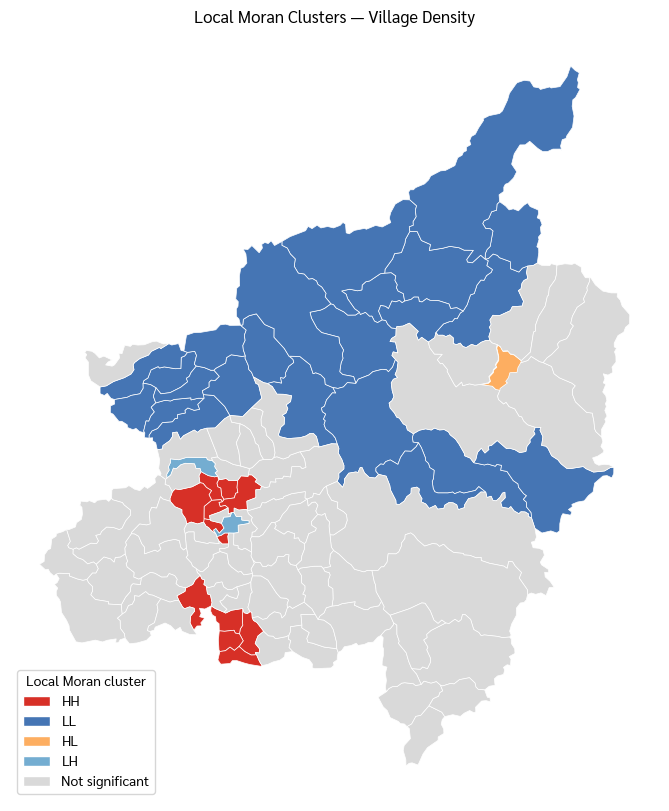

In [58]:
cluster_colors = {
    "HH": "#d73027",
    "LL": "#4575b4",
    "HL": "#fdae61",
    "LH": "#74add1",
    "Not significant": "#d9d9d9",
    "Unknown": "#ffffff"
}

fig_local_moran, ax = plt.subplots(
    figsize=(9, 10)
)

for cluster, color in cluster_colors.items():
    subset = phs_stats[
        phs_stats[
            "local_cluster"
        ] == cluster
    ]

    if not subset.empty:
        subset.plot(
            ax=ax,
            facecolor=color,
            edgecolor="white",
            linewidth=0.5
        )

legend_handles = [
    Patch(
        facecolor=color,
        edgecolor="white",
        label=label
    )
    for label, color in cluster_colors.items()
    if label != "Unknown"
]

ax.legend(
    handles=legend_handles,
    title="Local Moran cluster",
    loc="lower left"
)

ax.set_title(
    "Local Moran Clusters — Village Density"
)
ax.set_axis_off()

plt.show()

## 71. Exploratory significance caution

Local Moran ประเมินหลายพื้นที่พร้อมกัน จึงมีประเด็น multiple testing

ในบทนี้ใช้ `p < 0.05` เพื่อการเรียนรู้เชิง exploratory เท่านั้น

งานวิจัยจริงควรพิจารณา:

- multiple-testing correction
- robustness to spatial weights
- variable transformation
- data quality
- substantive environmental mechanism

# Part N — Advanced / MSc: Spatial-Weights Sensitivity

## 72. Queen vs Rook vs KNN

Spatial autocorrelation ไม่ได้ขึ้นอยู่กับ variable อย่างเดียว

ยังขึ้นอยู่กับคำถามว่า

> เรานิยาม “neighbor” อย่างไร?

## 73. Build Rook and KNN weights

In [59]:
w_rook = Rook.from_dataframe(
    phs_stats,
    use_index=True
)

w_rook.transform = "R"

centroids = phs_stats.geometry.centroid

coords = np.column_stack([
    centroids.x,
    centroids.y
])

w_knn4 = KNN.from_array(
    coords,
    k=4
)

w_knn4.transform = "R"

print("Queen islands:", w_queen.islands)
print("Rook islands :", w_rook.islands)
print("KNN islands  :", w_knn4.islands)

Queen islands: []
Rook islands : []
KNN islands  : []


## 74. Compare Global Moran's I across weights

In [60]:
weight_models = {
    "Queen": w_queen,
    "Rook": w_rook,
    "KNN k=4": w_knn4
}

sensitivity_rows = []

for name, w in weight_models.items():
    mi = Moran(
        y,
        w,
        permutations=999
    )

    sensitivity_rows.append({
        "Weights": name,
        "Moran_I": mi.I,
        "Expected_I": mi.EI,
        "p_sim": mi.p_sim
    })

weights_sensitivity = pd.DataFrame(
    sensitivity_rows
)

display(
    weights_sensitivity.round(4)
)

,Weights,Moran_I,Expected_I,p_sim
0,Queen,0.4926,-0.0109,0.001
1,Rook,0.5131,-0.0109,0.001
2,KNN k=4,0.5939,-0.0109,0.001


คำถามสำหรับ ป.โท:

> Spatial autocorrelation เป็น property ของข้อมูลเพียงอย่างเดียว หรือขึ้นอยู่กับวิธีนิยาม neighborhood ด้วย?

คำตอบคือ ต้องพิจารณาทั้งสองอย่าง

# Part O — Final Interactive Folium Map

## 75. JSON-safe helpers

In [61]:
def _json_safe_scalar(value):
    if value is None:
        return None

    try:
        if pd.isna(value):
            return None
    except Exception:
        pass

    if isinstance(value, pd.Timestamp):
        return value.isoformat()

    if isinstance(value, np.generic):
        value = value.item()

    if isinstance(
        value,
        (str, int, float, bool)
    ):
        return value

    return str(value)


def prepare_web_layer(
    gdf,
    fields,
    numeric_fields=None,
    target_crs="EPSG:4326"
):
    fields = [
        f for f in fields
        if f in gdf.columns
    ]

    fields = list(
        dict.fromkeys(fields)
    )

    web = gdf[
        fields + ["geometry"]
    ].copy()

    web = web.to_crs(
        target_crs
    )

    numeric_fields = (
        numeric_fields or []
    )

    for col in numeric_fields:
        if col in web.columns:
            web[col] = pd.to_numeric(
                web[col],
                errors="coerce"
            ).astype(float)

    for col in fields:
        if col not in numeric_fields:
            web[col] = web[col].map(
                _json_safe_scalar
            )

    return gpd.GeoDataFrame(
        web,
        geometry="geometry",
        crs=target_crs
    )


def to_safe_geojson(gdf):
    obj = json.loads(
        gdf.to_json()
    )

    json.dumps(
        obj,
        ensure_ascii=False
    )

    return obj

## 76. Prepare compact web layers

In [62]:
rings_web = prepare_web_layer(
    effective_rings_stats,
    fields=[
        "ring_label",
        "village_count",
        "density_corrected",
        "area_retained_pct"
    ],
    numeric_fields=[
        "village_count",
        "density_corrected",
        "area_retained_pct"
    ]
)

intersection_web = prepare_web_layer(
    ring_province,
    fields=[
        "ring_label",
        p_adm1_th,
        "piece_area_km2"
    ],
    numeric_fields=[
        "piece_area_km2"
    ]
)

local_web = prepare_web_layer(
    phs_stats,
    fields=[
        t_adm2_th,
        t_adm3_th,
        "village_density",
        "local_I",
        "local_p",
        "local_cluster"
    ],
    numeric_fields=[
        "village_density",
        "local_I",
        "local_p"
    ]
)

village_200_web = (
    village_200[
        [
            NAME_FIELD,
            "distance_km",
            "geometry"
        ]
    ]
    .copy()
    .to_crs(
        "EPSG:4326"
    )
)

## 77. Validate GeoJSON

In [63]:
rings_geojson = to_safe_geojson(
    rings_web
)

intersection_geojson = to_safe_geojson(
    intersection_web
)

local_geojson = to_safe_geojson(
    local_web
)

for name, obj in [
    ("Effective rings", rings_geojson),
    ("Ring-province intersection", intersection_geojson),
    ("Local Moran", local_geojson)
]:
    json.dumps(
        obj,
        ensure_ascii=False
    )

    print(
        name,
        "GeoJSON serialization OK"
    )

Effective rings GeoJSON serialization OK
Ring-province intersection GeoJSON serialization OK
Local Moran GeoJSON serialization OK


## 78. Basemap helper

In [64]:
def add_basemap(
    m,
    provider,
    name,
    show=False
):
    folium.TileLayer(
        tiles=provider.build_url(),
        attr=provider.html_attribution,
        name=name,
        overlay=False,
        control=True,
        show=show
    ).add_to(m)

## 79. Create final map

In [65]:
origin_ll = gpd.GeoSeries(
    [origin],
    crs="EPSG:32647"
).to_crs(
    "EPSG:4326"
).iloc[0]

m = folium.Map(
    location=[
        origin_ll.y,
        origin_ll.x
    ],
    zoom_start=6,
    tiles=None,
    control_scale=True
)

add_basemap(
    m,
    xyz.OpenTopoMap,
    "OpenTopoMap",
    show=True
)

add_basemap(
    m,
    xyz.Esri.WorldTopoMap,
    "Esri World Topographic",
    show=False
)

add_basemap(
    m,
    xyz.Esri.WorldImagery,
    "Esri World Imagery (Satellite)",
    show=False
)

## 80. Effective corrected-density rings

In [66]:
folium.GeoJson(
    rings_geojson,
    name="Corrected ring density",
    style_function=lambda feature: {
        "fillOpacity": 0.15,
        "color": "#444444",
        "weight": 1
    },
    tooltip=folium.GeoJsonTooltip(
        fields=[
            "ring_label",
            "village_count",
            "density_corrected",
            "area_retained_pct"
        ],
        aliases=[
            "Ring:",
            "Village count:",
            "Corrected density:",
            "Area retained (%):"
        ],
        localize=True
    )
).add_to(m)

## 81. Ring × Province intersection layer

In [67]:
folium.GeoJson(
    intersection_geojson,
    name="Ring × Province intersection",
    show=False,
    style_function=lambda feature: {
        "fillOpacity": 0.08,
        "color": "#666666",
        "weight": 0.6
    },
    tooltip=folium.GeoJsonTooltip(
        fields=[
            "ring_label",
            p_adm1_th,
            "piece_area_km2"
        ],
        aliases=[
            "Ring:",
            "Province:",
            "Area (km²):"
        ],
        localize=True
    )
).add_to(m)

## 82. Village points with FastMarkerCluster

In [68]:
cluster_data = [
    [
        geom.y,
        geom.x,
        str(name),
        float(dist)
    ]
    for geom, name, dist in zip(
        village_200_web.geometry,
        village_200_web[
            NAME_FIELD
        ],
        village_200_web[
            "distance_km"
        ]
    )
]

callback = '''
function (row) {
    var marker = L.circleMarker(
        new L.LatLng(row[0], row[1]),
        {
            radius: 3,
            weight: 1,
            fillOpacity: 0.7
        }
    );

    marker.bindTooltip(
        row[2] + "<br>Distance: "
        + row[3].toFixed(1)
        + " km"
    );

    return marker;
};
'''

FastMarkerCluster(
    data=cluster_data,
    callback=callback,
    name="Village points ≤ 200 km",
    show=False
).add_to(m)

## 83. Local Moran layer

In [69]:
def local_style(feature):
    cluster = (
        feature[
            "properties"
        ][
            "local_cluster"
        ]
    )

    color = cluster_colors.get(
        cluster,
        "#ffffff"
    )

    return {
        "fillColor": color,
        "fillOpacity": 0.65,
        "color": "#ffffff",
        "weight": 1
    }


folium.GeoJson(
    local_geojson,
    name="Local Moran — Phitsanulok Tambons",
    show=False,
    style_function=local_style,
    tooltip=folium.GeoJsonTooltip(
        fields=[
            t_adm3_th,
            t_adm2_th,
            "village_density",
            "local_cluster",
            "local_p"
        ],
        aliases=[
            "Tambon:",
            "District:",
            "Village density:",
            "Local cluster:",
            "Permutation p:"
        ],
        localize=True
    )
).add_to(m)

## 84. Origin marker + Layer Control

In [70]:
folium.Marker(
    location=[
        origin_ll.y,
        origin_ll.x
    ],
    tooltip=(
        "Mueang Phitsanulok geometric centroid"
    )
).add_to(m)

folium.LayerControl(
    collapsed=False
).add_to(m)

m

# Part P — Publication-quality Maps

## 85. North arrow + scale bar

In [71]:
def add_north_arrow(
    ax,
    x=0.92,
    y=0.10,
    size=0.09
):
    ax.annotate(
        "N",
        xy=(x, y + size),
        xytext=(x, y),
        xycoords=ax.transAxes,
        textcoords=ax.transAxes,
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold",
        arrowprops=dict(
            arrowstyle="-|>",
            linewidth=1.4,
            color="black"
        )
    )


def add_scalebar(
    ax,
    scale_km=50
):
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    width = xmax - xmin
    height = ymax - ymin

    x0 = xmin + 0.07 * width
    y0 = ymin + 0.05 * height
    x1 = x0 + scale_km * 1000

    ax.plot(
        [x0, x1],
        [y0, y0],
        color="black",
        linewidth=3
    )

    ax.text(
        (x0 + x1) / 2,
        y0 + 0.015 * height,
        f"{scale_km} km",
        ha="center",
        fontsize=8
    )

## 86. Publication Map 1 — Effective Rings

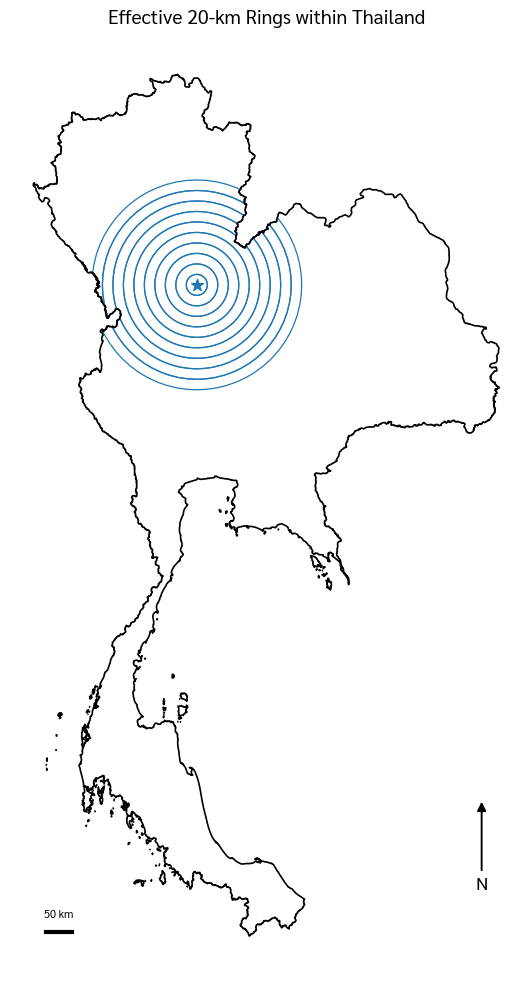

In [72]:
fig_pub_effective, ax = plt.subplots(
    figsize=(10, 10)
)

effective_rings.boundary.plot(
    ax=ax,
    linewidth=0.9
)

thailand_mask.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1.2
)

gpd.GeoSeries(
    [origin],
    crs="EPSG:32647"
).plot(
    ax=ax,
    markersize=80,
    marker="*"
)

ax.set_title(
    "Effective 20-km Rings within Thailand",
    fontsize=14,
    fontweight="bold"
)

ax.set_axis_off()

add_north_arrow(ax)
add_scalebar(ax, 50)

plt.tight_layout()
plt.show()

## 87. Publication Map 2 — Corrected Ring Density

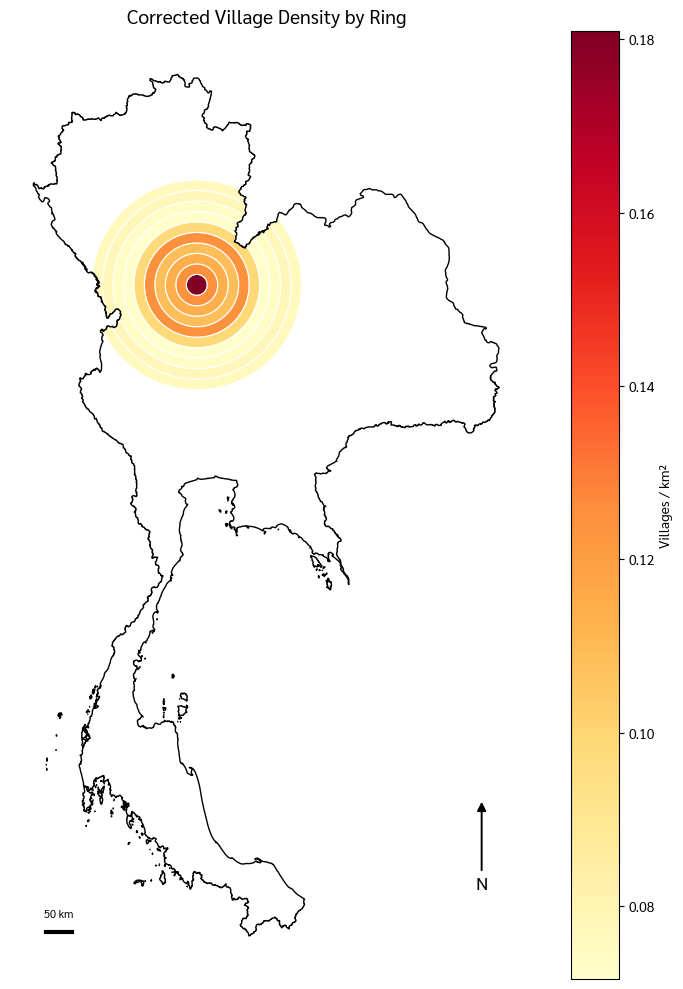

In [73]:
fig_pub_corrected, ax = plt.subplots(
    figsize=(10, 10)
)

effective_rings_stats.plot(
    ax=ax,
    column="density_corrected",
    cmap="YlOrRd",
    legend=True,
    edgecolor="white",
    linewidth=0.8,
    legend_kwds={
        "label": "Villages / km²"
    }
)

thailand_mask.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1.0
)

ax.set_title(
    "Corrected Village Density by Ring",
    fontsize=14,
    fontweight="bold"
)

ax.set_axis_off()

add_north_arrow(ax)
add_scalebar(ax, 50)

plt.tight_layout()
plt.show()

## 88. Publication Map 3 — Ring × Province Intersection

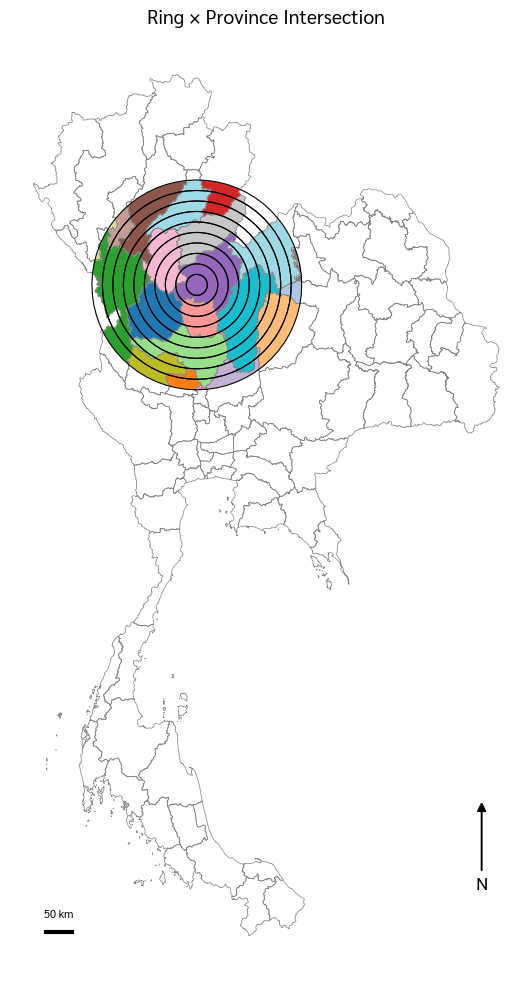

In [74]:
fig_pub_intersection, ax = plt.subplots(
    figsize=(10, 10)
)

ring_province.plot(
    ax=ax,
    column=p_adm1_th,
    categorical=True,
    legend=False,
    edgecolor="white",
    linewidth=0.3
)

province_utm.boundary.plot(
    ax=ax,
    color="gray",
    linewidth=0.5
)

rings.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.8
)

ax.set_title(
    "Ring × Province Intersection",
    fontsize=14,
    fontweight="bold"
)

ax.set_axis_off()

add_north_arrow(ax)
add_scalebar(ax, 50)

plt.tight_layout()
plt.show()

## 89. Publication Map 4 — Phitsanulok Village Density

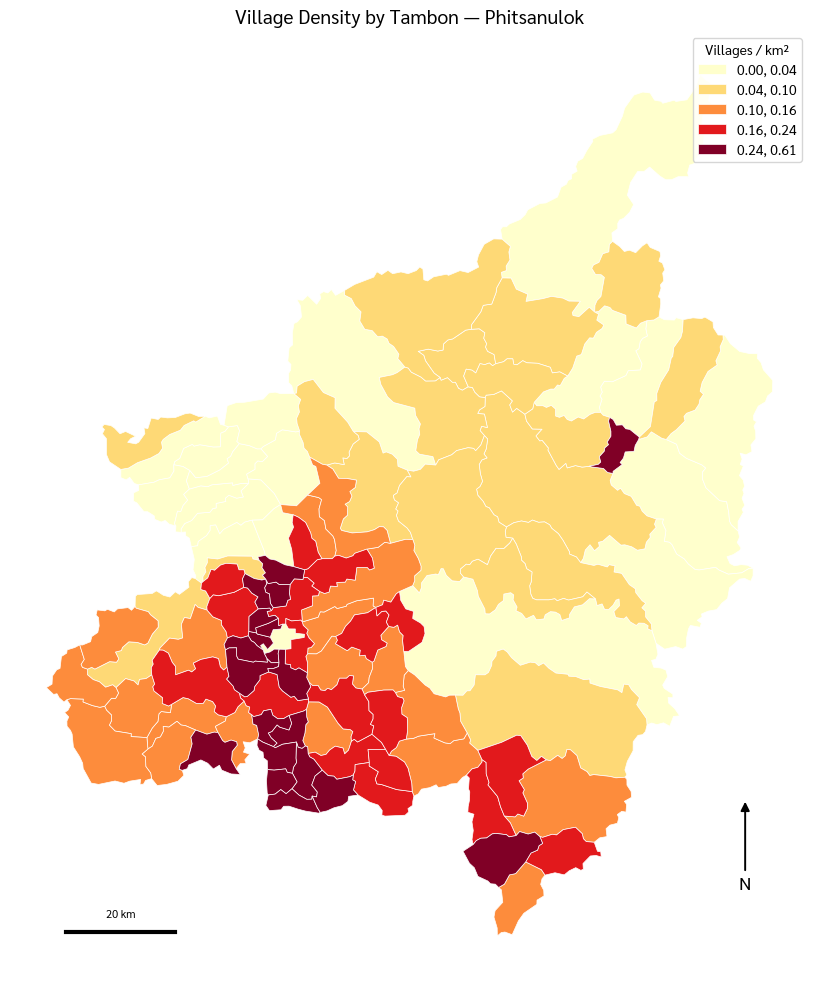

In [75]:
fig_pub_phs_density, ax = plt.subplots(
    figsize=(9, 10)
)

phs_stats.plot(
    ax=ax,
    column="village_density",
    scheme="Quantiles",
    k=5,
    cmap="YlOrRd",
    legend=True,
    edgecolor="white",
    linewidth=0.5,
    legend_kwds={
        "title": "Villages / km²"
    }
)

ax.set_title(
    "Village Density by Tambon — Phitsanulok",
    fontsize=14,
    fontweight="bold"
)

ax.set_axis_off()

add_north_arrow(ax)
add_scalebar(ax, 20)

plt.tight_layout()
plt.show()

## 90. Publication Map 5 — Local Moran Clusters

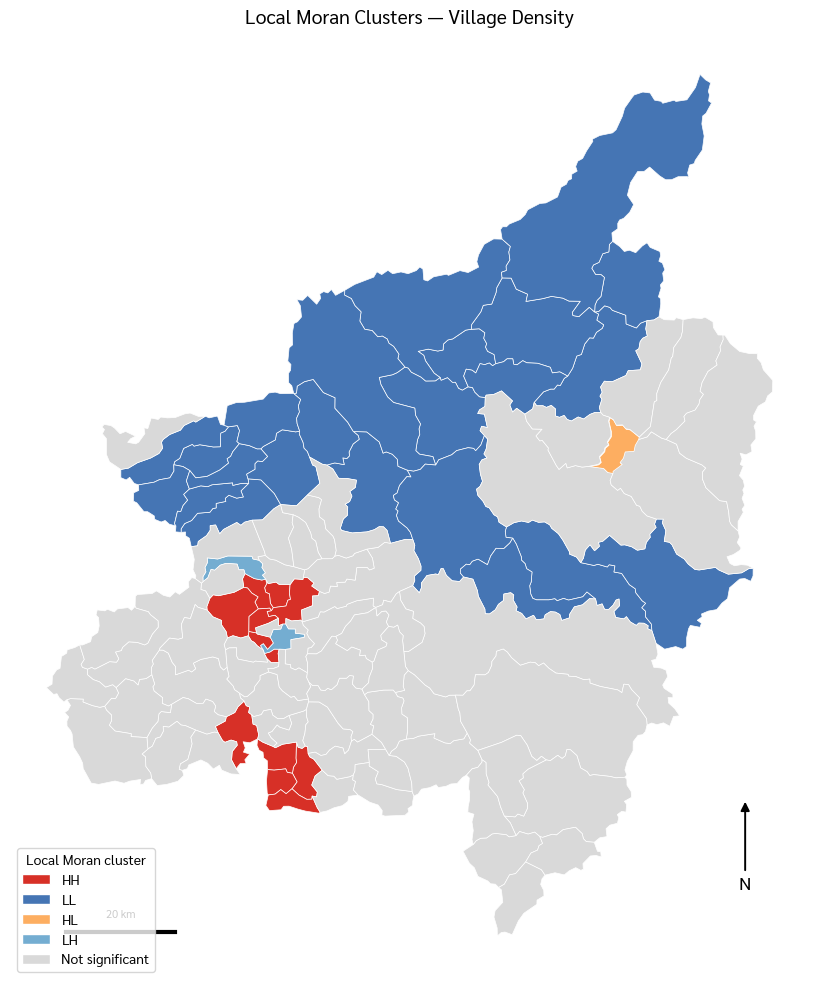

In [76]:
fig_pub_local, ax = plt.subplots(
    figsize=(9, 10)
)

for cluster, color in cluster_colors.items():
    subset = phs_stats[
        phs_stats[
            "local_cluster"
        ] == cluster
    ]

    if not subset.empty:
        subset.plot(
            ax=ax,
            facecolor=color,
            edgecolor="white",
            linewidth=0.5
        )

legend_handles = [
    Patch(
        facecolor=color,
        edgecolor="white",
        label=label
    )
    for label, color in cluster_colors.items()
    if label != "Unknown"
]

ax.legend(
    handles=legend_handles,
    title="Local Moran cluster",
    loc="lower left"
)

ax.set_title(
    "Local Moran Clusters — Village Density",
    fontsize=14,
    fontweight="bold"
)

ax.set_axis_off()

add_north_arrow(ax)
add_scalebar(ax, 20)

plt.tight_layout()
plt.show()

# Part Q — Export

## 91. Output folders

In [77]:
MAP_DIR = OUTPUT_DIR / "maps"
VECTOR_DIR = OUTPUT_DIR / "vectors"
TABLE_DIR = OUTPUT_DIR / "tables"
HTML_DIR = OUTPUT_DIR / "html"

for folder in [
    MAP_DIR,
    VECTOR_DIR,
    TABLE_DIR,
    HTML_DIR
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )

## 92. Export PNG 300 dpi

In [78]:
fig_pub_effective.savefig(
    MAP_DIR / "effective_rings_300dpi.png",
    dpi=300,
    bbox_inches="tight"
)

fig_pub_corrected.savefig(
    MAP_DIR / "corrected_ring_density_300dpi.png",
    dpi=300,
    bbox_inches="tight"
)

fig_pub_intersection.savefig(
    MAP_DIR / "ring_province_intersection_300dpi.png",
    dpi=300,
    bbox_inches="tight"
)

fig_pub_phs_density.savefig(
    MAP_DIR / "phitsanulok_village_density_300dpi.png",
    dpi=300,
    bbox_inches="tight"
)

fig_pub_local.savefig(
    MAP_DIR / "local_moran_clusters_300dpi.png",
    dpi=300,
    bbox_inches="tight"
)

fig_density_compare.savefig(
    MAP_DIR / "naive_vs_corrected_density_300dpi.png",
    dpi=300,
    bbox_inches="tight"
)

fig_moran_scatter.savefig(
    MAP_DIR / "moran_scatterplot_300dpi.png",
    dpi=300,
    bbox_inches="tight"
)

print("PNG figures exported.")

PNG figures exported.


## 93. Export Thailand boundary GPKG

In [79]:
thailand_gpkg = (
    VECTOR_DIR
    / "thailand_boundary.gpkg"
)

if thailand_gpkg.exists():
    thailand_gpkg.unlink()

thailand_mask.to_file(
    thailand_gpkg,
    layer="thailand",
    driver="GPKG"
)

print("Saved:", thailand_gpkg)

Saved: /content/gis08_outputs/vectors/thailand_boundary.gpkg


## 94. Export effective rings and overlay GPKG

In [80]:
effective_gpkg = (
    VECTOR_DIR
    / "effective_rings.gpkg"
)

if effective_gpkg.exists():
    effective_gpkg.unlink()

effective_rings_stats.to_file(
    effective_gpkg,
    layer="effective_rings",
    driver="GPKG"
)

intersection_gpkg = (
    VECTOR_DIR
    / "ring_province_intersection.gpkg"
)

if intersection_gpkg.exists():
    intersection_gpkg.unlink()

ring_province.to_file(
    intersection_gpkg,
    layer="ring_province",
    driver="GPKG"
)

print("Saved:", effective_gpkg)
print("Saved:", intersection_gpkg)

Saved: /content/gis08_outputs/vectors/effective_rings.gpkg
Saved: /content/gis08_outputs/vectors/ring_province_intersection.gpkg


## 95. Export spatial-statistics GPKG

In [81]:
stats_gpkg = (
    VECTOR_DIR
    / "tambon_spatial_statistics.gpkg"
)

if stats_gpkg.exists():
    stats_gpkg.unlink()

phs_stats.to_file(
    stats_gpkg,
    layer="tambon_spatial_stats",
    driver="GPKG"
)

print("Saved:", stats_gpkg)

Saved: /content/gis08_outputs/vectors/tambon_spatial_statistics.gpkg


## 96. Export CSV tables

In [82]:
ring_density.to_csv(
    TABLE_DIR / "corrected_ring_density.csv",
    index=False,
    encoding="utf-8-sig"
)

ring_province_area.to_csv(
    TABLE_DIR / "ring_province_area.csv",
    index=False,
    encoding="utf-8-sig"
)

global_moran_table.to_csv(
    TABLE_DIR / "global_moran_results.csv",
    index=False,
    encoding="utf-8-sig"
)

weights_sensitivity.to_csv(
    TABLE_DIR / "weights_sensitivity.csv",
    index=False,
    encoding="utf-8-sig"
)

phs_stats[
    [
        t_adm2_th,
        t_adm3_th,
        "village_count",
        "area_km2",
        "village_density",
        "n_neighbors",
        "local_I",
        "local_p",
        "local_cluster"
    ]
].to_csv(
    TABLE_DIR / "local_moran_results.csv",
    index=False,
    encoding="utf-8-sig"
)

print("CSV tables exported.")

CSV tables exported.


## 97. Export Folium HTML

In [83]:
html_path = (
    HTML_DIR
    / "final_spatial_analysis_interactive.html"
)

m.save(
    html_path
)

print("Saved:", html_path)

Saved: /content/gis08_outputs/html/final_spatial_analysis_interactive.html


## 98. Inspect outputs

In [84]:
for p in sorted(
    OUTPUT_DIR.rglob("*")
):
    if p.is_file():
        print(
            p.relative_to(
                OUTPUT_DIR
            ),
            f"({p.stat().st_size/1024:,.1f} KB)"
        )

html/final_spatial_analysis_interactive.html (2,156.0 KB)
maps/corrected_ring_density_300dpi.png (370.4 KB)
maps/effective_rings_300dpi.png (357.1 KB)
maps/local_moran_clusters_300dpi.png (506.8 KB)
maps/moran_scatterplot_300dpi.png (196.2 KB)
maps/naive_vs_corrected_density_300dpi.png (145.6 KB)
maps/phitsanulok_village_density_300dpi.png (498.8 KB)
maps/ring_province_intersection_300dpi.png (616.3 KB)
tables/corrected_ring_density.csv (1.5 KB)
tables/global_moran_results.csv (0.1 KB)
tables/local_moran_results.csv (11.8 KB)
tables/ring_province_area.csv (5.6 KB)
tables/weights_sensitivity.csv (0.2 KB)
vectors/effective_rings.gpkg (136.0 KB)
vectors/ring_province_intersection.gpkg (344.0 KB)
vectors/tambon_spatial_statistics.gpkg (212.0 KB)
vectors/thailand_boundary.gpkg (252.0 KB)


# Concept Check

1. Dissolve ต่างจาก Clip อย่างไร?
2. Clip ต่างจาก Intersection อย่างไร?
3. Difference ตอบคำถามแบบใด?
4. ทำไม numerator และ denominator ต้องมี spatial support เดียวกัน?
5. ทำไม full ring area ทำให้ density ผิดเมื่อข้อมูลมีเฉพาะประเทศไทย?
6. Spatial weights คืออะไร?
7. Queen contiguity กำหนด neighbor อย่างไร?
8. Global Moran's I ตอบคำถามอะไร?
9. ทำไมต้องดู Expected I และ permutation p-value ร่วมกับ Moran's I?
10. Moran scatterplot quadrants HH/LL/HL/LH หมายถึงอะไร?
11. Global Moran ต่างจาก Local Moran อย่างไร?
12. ทำไม spatial weights ที่ต่างกันอาจให้ Moran's I ต่างกัน?

# Exercise 1 — Clip another distance

เลือก cumulative buffer เช่น 100 km หรือ 160 km

ทำ:

```text
Buffer
↓
Clip by Thailand
↓
Full area
↓
Effective area
↓
Area retained %
```

แล้วเปรียบเทียบกับ 200-km buffer

# Exercise 2 — Clip vs Intersection

ใช้ 180–200 km ring

ทำทั้ง:

```python
gpd.clip()
```

และ

```python
gpd.overlay(..., how="intersection")
```

อธิบายว่าผล geometry และ attributes ต่างกันอย่างไร

# Exercise 3 — Naive vs Corrected Density

เลือกอย่างน้อย 3 rings

สร้างตาราง:

```text
Ring
Village count
Full area
Effective area
Naive density
Corrected density
Bias %
```

อธิบายว่าทำไม bias ไม่เท่ากันทุก ring

# Exercise 4 — Moran's I with another variable

ทดลองใช้:

```text
village_count
```

แทน

```text
village_density
```

แล้วเปรียบเทียบ Global Moran's I

ถาม:

> Count และ Density ให้ spatial pattern เหมือนกันหรือไม่?

# Exercise 5 — Interpret the Moran Scatterplot

เลือกอย่างน้อย 4 Tambons จากแต่ละ quadrant:

```text
HH
LL
HL
LH
```

อธิบายว่า standardized value และ spatial lag หมายถึงอะไร

# MSc Challenge — Spatial-Weights Sensitivity

เปรียบเทียบ

```text
Queen
Rook
KNN k=4
```

ในด้าน

- average number of neighbors
- islands
- Moran's I
- permutation p-value

อภิปรายว่า

> ผล spatial autocorrelation มี sensitivity ต่อ spatial conceptualization มากน้อยเพียงใด?

และพิจารณาว่า weights แบบใดสอดคล้องกับคำถามสิ่งแวดล้อมของงานมากที่สุด

# Final Course Summary — Notebooks 01–08

เส้นทางการเรียนรู้ของชุดนี้:

$$
01:\ What\ is\ GIS\ data?
$$

$$
02:\ Can\ I\ measure\ it\ correctly?
$$

$$
03:\ What\ patterns\ can\ I\ summarize?
$$

$$
04:\ How\ are\ layers\ spatially\ related?
$$

$$
05:\ How\ do\ I\ manage\ detailed\ polygons?
$$

$$
06:\ How\ do\ points\ become\ spatial\ information?
$$

$$
07:\ How\ does\ spatial\ pattern\ change\ with\ distance?
$$

$$
\boxed{
08:\ How\ do\ I\ integrate\ layers\ and\ test\ spatial\ pattern?
}
$$

ภาพรวม workflow:

```text
Inspect
↓
Map
↓
Query
↓
Measure
↓
Relate
↓
Aggregate
↓
Distance
↓
Overlay
↓
Normalize
↓
Spatial Statistics
↓
Communicate
```

หลักสำคัญที่สุด:

> **Correct-looking geometry ≠ correct measurement**

> **Count ≠ Density**

> **Spatial support matters**

> **A visual cluster ≠ statistically demonstrated spatial autocorrelation**

> **Spatial statistics depend on both the data and the definition of neighborhood**

> **A map is an analytical argument, not merely decoration**